## Name: Mustafa Erdem
## Date : 05/12/2026
## Exercise : Final Project  
###  Newark Liberty International Airport (EWR) – United Airlines Flight Analysis (2025)

This project analyzes United Airlines flight data specifically for departures from Newark Liberty International Airport (EWR) in 2025. The focus is on flight delays, scheduling accuracy, and operational performance.

### Research Questions
- 1) Which United Airlines aircraft (tail numbers) are associated with the highest number of delayed departures from Newark Liberty International Airport in 2025?
- 2) Which destinations have the highest average departure delays for United Airlines flights departing from Newark Liberty International Airport in 2025?
- 3) What are the main causes of delays for United Airlines flights departures from Newark Liberty International Airport in 2025?
- 4) Do longer United Airlines flights tend to experience higher departure delays from Newark Liberty International Airport in 2025?
- 5) Which time periods (morning, afternoon, evening, night) are associated with the highest number of delayed departures for United Airlines flights from Newark Liberty International Airport in 2025?

In [63]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

Pandas version: 3.0.2
Matplotlib version: 3.10.9
Seaborn version: 0.13.2


## Data Cleaning: Removing Corrupted Rows

Before loading the dataset into pandas, the file was cleaned by removing the last two rows, which were causing parsing errors.

This step is necessary because the dataset contains corrupted or incomplete lines at the end of the file, which can break CSV parsing.

After removing these rows, the cleaned data is saved into a new file (`clean_file.csv`) and then used for further analysis.

In [65]:
with open("Detailed_Statistics_Departures.csv", "r") as f:
    lines = f.readlines()

with open("clean_file.csv", "w") as f:
    f.writelines(lines[:-2])

##  Removed Rows

The following rows were removed from the dataset because they were causing parsing errors. 

In [66]:
for line in lines[-2:]:
    print(line)



 SOURCE: Bureau of Transportation Statistics


In [67]:
df = pd.read_csv("clean_file.csv", skiprows=7)  ## The first 7 rows are skipped because they contain metadata,
                                                ## and the actual data table begins afterward.

# Removed Rows
The following rows were removed from the dataset.

In [68]:
count = 0
for line in lines:
    if count < 7:
        count += 1
        print(line)

Detailed Statistics Departures  

Origin Airport: Newark, NJ: Newark Liberty International (EWR)

Airline: United Airlines Inc. (UA)

Month(s): January, February, March, April, May, June, July, August, September, October, November, and December

Day(s): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 and 31

Year(s): 2025





##  Dataset Size

The cleaned dataset contains **66,747 flight records**, confirming that the data was successfully loaded and is ready for analysis.

In [69]:
df.shape 

(66747, 17)

In [70]:
df.columns  ## The column names were reviewed for clarity and usability.
            ## Long or complex column names may be shortened or standardized to improve readability and make analysis easier.

Index(['Carrier Code', 'Date (MM/DD/YYYY)', 'Flight Number', 'Tail Number',
       'Destination Airport', 'Scheduled departure time',
       'Actual departure time', 'Scheduled elapsed time (Minutes)',
       'Actual elapsed time (Minutes)', 'Departure delay (Minutes)',
       'Wheels-off time', 'Taxi-Out time (Minutes)', 'Delay Carrier (Minutes)',
       'Delay Weather (Minutes)', 'Delay National Aviation System (Minutes)',
       'Delay Security (Minutes)', 'Delay Late Aircraft Arrival (Minutes)'],
      dtype='str')

In [71]:
df.info() ## Only the “Tail Number” column contains missing values.

<class 'pandas.DataFrame'>
RangeIndex: 66747 entries, 0 to 66746
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Carrier Code                              66747 non-null  str  
 1   Date (MM/DD/YYYY)                         66747 non-null  str  
 2   Flight Number                             66747 non-null  int64
 3   Tail Number                               65850 non-null  str  
 4   Destination Airport                       66747 non-null  str  
 5   Scheduled departure time                  66747 non-null  str  
 6   Actual departure time                     66747 non-null  str  
 7   Scheduled elapsed time (Minutes)          66747 non-null  int64
 8   Actual elapsed time (Minutes)             66747 non-null  int64
 9   Departure delay (Minutes)                 66747 non-null  int64
 10  Wheels-off time                           66747 non-null  str  
 11  

##  Descriptive Statistics Summary

On average, flights have a departure delay of about 15 minutes, while taxi-out time averages around 26 minutes. Most delay categories such as weather, security, and national aviation system delays have very low median values (often 0), indicating that these delays do not occur frequently.

However, the maximum values show significant outliers in several columns (for example, very large departure delays and carrier delays), suggesting that while most flights experience minor disruptions, a small number of flights suffer extreme delays. This difference between average and maximum values highlights variability in airline performance and the impact of exceptional cases.

In [72]:
display(df.describe().round(3))

,Flight Number,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
count,66747.000,66747.000,66747.000,66747.000,66747.000,66747.000,66747.000,66747.000,66747.000,66747.000
mean,1582.867,223.546,214.620,15.345,26.279,4.918,0.926,5.103,0.002,8.314
std,697.150,93.832,97.658,54.233,16.384,24.433,14.673,18.952,0.526,34.999
min,42.000,65.000,0.000,-32.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1184.000,160.000,152.000,-6.000,17.000,0.000,0.000,0.000,0.000,0.000
50%,1625.000,193.000,192.000,-3.000,22.000,0.000,0.000,0.000,0.000,0.000
75%,2151.000,288.000,288.000,11.000,29.000,0.000,0.000,0.000,0.000,0.000
max,3012.000,687.000,721.000,1240.000,379.000,899.000,871.000,654.000,136.000,1112.000


In [73]:
display(df)

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,UA,01/01/2025,211,N828UA,BNA,17:29,17:21,157,156,-8,17:46,25,0,0,0,0,0
1,UA,01/01/2025,212,N69819,TPA,20:25,20:34,185,213,9,21:34,60,9,0,28,0,0
2,UA,01/01/2025,293,N38446,RSW,06:45,06:38,195,179,-7,06:52,14,0,0,0,0,0
3,UA,01/01/2025,363,N76054,HNL,09:05,09:09,684,664,4,09:33,24,0,0,0,0,0
4,UA,01/01/2025,403,N27252,FLL,10:00,10:11,197,186,11,10:31,20,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66742,UA,12/31/2025,2678,N894UA,JAX,13:00,12:55,162,136,-5,13:12,17,0,0,0,0,0
66743,UA,12/31/2025,2679,N41140,LAX,10:15,10:11,380,353,-4,10:27,16,0,0,0,0,0
66744,UA,12/31/2025,2691,N17306,MIA,20:15,20:12,202,172,-3,20:31,19,0,0,0,0,0
66745,UA,12/31/2025,2692,N12021,LAX,08:40,08:36,365,353,-4,08:56,20,0,0,0,0,0


## Column Name Cleaning

Column names were cleaned and standardized to improve readability and consistency. This included removing unnecessary text (e.g., "Arrival", "(Minutes)"), shortening terms (e.g., "departure" → "dep", "Number" → "num"), trimming spaces, replacing spaces with underscores, and converting all names to lowercase.

The updated column names are displayed to verify the changes.

In [74]:
df.columns = (
    df.columns
    .str.replace("Arrival", "")
    .str.replace("departure", "dep")
    .str.replace("Number", "num")
    .str.replace("(MM/DD/YYYY)", "")
    .str.replace("(Minutes)", "")
    .str.replace("National Aviation System", "nas")
    .str.strip()
    .str.replace(" ", "_")
    .str.lower())
display(df.columns)

Index(['carrier_code', 'date', 'flight_num', 'tail_num', 'destination_airport',
       'scheduled_dep_time', 'actual_dep_time', 'scheduled_elapsed_time',
       'actual_elapsed_time', 'departure_delay', 'wheels-off_time',
       'taxi-out_time', 'delay_carrier', 'delay_weather', 'delay_nas',
       'delay_security', 'delay_late_aircraft'],
      dtype='str')

## Data Overview and Missing Values

The total number of flights is calculated using the number of rows in the dataset. Additionally, missing values are identified for each column to understand data completeness and detect potential issues before analysis.

In [75]:
total_flights = df.shape[0]
display(df.isna().sum())
print("-" * 50)
print(f"Total flights: {total_flights}") 

carrier_code                0
date                        0
flight_num                  0
tail_num                  897
destination_airport         0
scheduled_dep_time          0
actual_dep_time             0
scheduled_elapsed_time      0
actual_elapsed_time         0
departure_delay             0
wheels-off_time             0
taxi-out_time               0
delay_carrier               0
delay_weather               0
delay_nas                   0
delay_security              0
delay_late_aircraft         0
dtype: int64

--------------------------------------------------
Total flights: 66747


In [76]:
df[df.isna().any(axis=1)] # Display rows with any missing values for virtual inspection

,carrier_code,date,flight_num,tail_num,destination_airport,scheduled_dep_time,actual_dep_time,scheduled_elapsed_time,actual_elapsed_time,departure_delay,wheels-off_time,taxi-out_time,delay_carrier,delay_weather,delay_nas,delay_security,delay_late_aircraft
526,UA,01/03/2025,2279,NaN,PBI,13:08,00:00,190,0,0,00:00,0,0,0,0,0,0
613,UA,01/04/2025,1155,NaN,AUS,12:59,00:00,259,0,0,00:00,0,0,0,0,0,0
775,UA,01/05/2025,702,NaN,LAX,20:35,00:00,383,0,0,00:00,0,0,0,0,0,0
1055,UA,01/06/2025,1973,NaN,IAH,12:30,00:00,245,0,0,00:00,0,0,0,0,0,0
1232,UA,01/07/2025,1818,NaN,CLE,08:25,00:00,106,0,0,00:00,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65920,UA,12/27/2025,2044,NaN,RSW,06:55,00:00,196,0,0,00:00,0,0,0,0,0,0
65922,UA,12/27/2025,2075,NaN,PBI,08:59,00:00,194,0,0,00:00,0,0,0,0,0,0
65959,UA,12/27/2025,2444,NaN,FLL,09:15,00:00,199,0,0,00:00,0,0,0,0,0,0
65974,UA,12/27/2025,2669,NaN,TPA,08:59,00:00,186,0,0,00:00,0,0,0,0,0,0


## Identifying Cancelled Flights

Flights with an actual departure time of "00:00" are identified as cancelled or non-departed. These records are filtered, and the total number of cancelled flights is calculated for further analysis.

In [77]:
print(df[df["actual_dep_time"] == "00:00"].shape)
canceled_flights = df[df["actual_dep_time"] == "00:00"].shape[0]
print(f"Canceled flights: {canceled_flights}")

(897, 17)
Canceled flights: 897


## Flight Cancellation Rate

The analysis indicates that approximately `1.34% of flights were classified as cancelled or non-departed`, based on records with no recorded departure activity (e.g., "00:00" actual departure time). These observations were excluded from subsequent analyses to ensure that delay metrics are computed only from completed flights.

In [78]:
df = df[df["tail_num"].notna()]
percentage_canceled = (canceled_flights / total_flights) * 100
print(f"Percentage of canceled flights: {percentage_canceled:.2f}%")

Percentage of canceled flights: 1.34%


In [79]:
df.isna().sum() ## After filtering out canceled flights, there are no missing values in the dataset.

carrier_code              0
date                      0
flight_num                0
tail_num                  0
destination_airport       0
scheduled_dep_time        0
actual_dep_time           0
scheduled_elapsed_time    0
actual_elapsed_time       0
departure_delay           0
wheels-off_time           0
taxi-out_time             0
delay_carrier             0
delay_weather             0
delay_nas                 0
delay_security            0
delay_late_aircraft       0
dtype: int64

## Research Results
#### Which United Airlines aircraft (tail numbers) are associated with the highest number of delayed departures from Newark Liberty International Airport in 2025?

In [80]:
df_delayed = df[df["departure_delay"] > 0]
tail_delays = df_delayed.groupby("tail_num").size()

## Analysis

To determine which United Airlines aircraft are associated with the highest number of delayed departures in 2025, flights with a departure delay greater than zero minutes were classified as delayed.

The dataset was grouped by aircraft tail number, and the total number of delayed departures was calculated for each aircraft.

The results show that the following aircraft have the highest number of delayed departures:

- N13110 – 116 delays
- N19141 – 116 delays
- N14115 – 103 delays
- N34137 – 102 delays
- N48127 – 102 delays
- N13138 – 94 delays
- N13113 – 94 delays
- N17139 – 93 delays
- N12116 – 91 delays
- N14118 – 87 delays

In [81]:
tail_delays = tail_delays.sort_values(ascending=False)
top_tail_delays = tail_delays.head(10)

print(top_tail_delays)

tail_num
N13110    116
N19141    116
N14115    103
N34137    102
N48127    102
N13138     94
N13113     94
N17139     93
N12116     91
N14118     87
dtype: int64


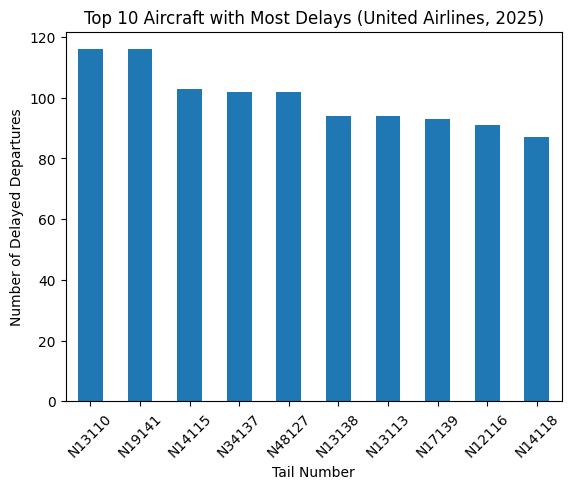

In [82]:

top_tail_delays.plot(kind='bar')
plt.title("Top 10 Aircraft with Most Delays (United Airlines, 2025)")
plt.xlabel("Tail Number")
plt.ylabel("Number of Delayed Departures")
plt.xticks(rotation=45)
plt.show()

### Which destinations have the highest average departure delays for United Airlines flights departing from Newark Liberty International Airport in 2025?

The results show that average departure delays vary significantly across United Airlines destinations from Newark Liberty International Airport in 2025. Louisville International Airport (SDF) has the highest average delay at 117.40 minutes, standing out as a clear outlier. Other higher-delay destinations include Eppley Airfield (OMA) and Kansas City International Airport (MCI), while most remaining airports such as Memphis (MEM), Buffalo (BUF), and Minneapolis–Saint Paul (MSP) cluster around 29–35 minutes. Honolulu International Airport (HNL) shows the lowest average among the top destinations at 28.50 minutes. Overall, most routes experience moderate delays, with a few destinations showing unusually high averages.

In [83]:
avg_delay = df.groupby("destination_airport")["departure_delay"].mean().reset_index()
avg_delay.columns = ["destination_airport", "average_departure_delay"]
avg_delay["average_departure_delay"] = avg_delay["average_departure_delay"].round(2)
avg_delay = avg_delay.sort_values(by="average_departure_delay", ascending=False)

### Average Departure Delays by Destination 

The table below shows the destinations with the highest average departure delays for United Airlines flights departing from Newark Liberty International Airport in 2025. The values represent the mean departure delay (in minutes) for each destination, calculated across all recorded flights in the dataset.

In [84]:
display(avg_delay.head(10))

,destination_airport,average_departure_delay
58,SDF,117.40
40,OMA,68.25
30,MCI,42.39
32,MEM,35.40
7,BUF,34.79
49,PWM,31.11
34,MSN,30.93
35,MSP,30.16
68,SYR,29.95
22,HNL,28.50


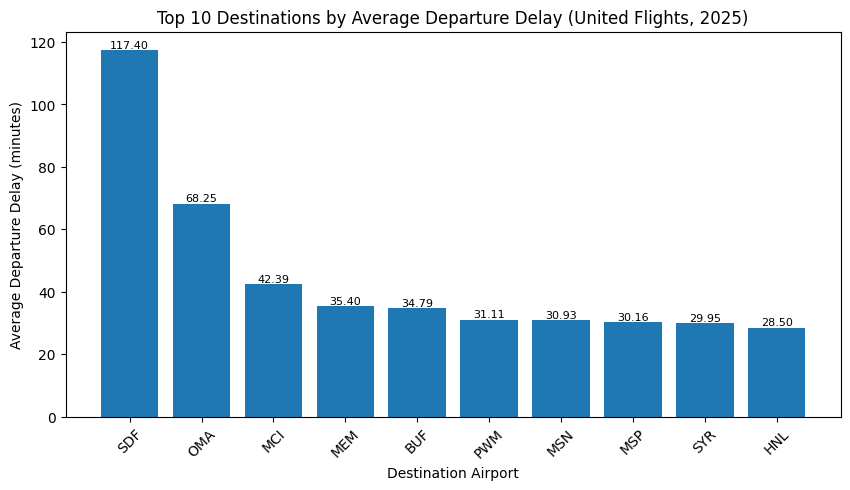

In [85]:
top10 = avg_delay.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10["destination_airport"], top10["average_departure_delay"])

plt.title("Top 10 Destinations by Average Departure Delay (United Flights, 2025)")
plt.xlabel("Destination Airport")
plt.ylabel("Average Departure Delay (minutes)")
plt.xticks(rotation=45)

# add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}",
             ha='center', va='bottom', fontsize=8)

plt.show()

### What are the main causes of delays for United Airlines flights departures from Newark Liberty International Airport in 2025?

### Analysis

To identify the main causes of delays for United Airlines flights in 2025, total delay minutes were calculated for each delay category: carrier, weather, NAS (National Aviation System), security, and late aircraft arrival.

The results are as follows:

- Late Aircraft: 554,914 minutes
- NAS (Air Traffic / Airport Congestion): 340,595 minutes
- Carrier: 328,249 minutes
- Weather: 61,819 minutes
- Security: 136 minutes

In [86]:
delay_totals = {
    "Carrier": df["delay_carrier"].sum(),
    "Weather": df["delay_weather"].sum(),
    "NAS": df["delay_nas"].sum(),
    "Security": df["delay_security"].sum(),
    "Late Aircraft": df["delay_late_aircraft"].sum()
}

import pandas as pd
delay_df = pd.Series(delay_totals).sort_values(ascending=False)

print(delay_df)

Late Aircraft    554914
NAS              340595
Carrier          328249
Weather           61819
Security            136
dtype: int64


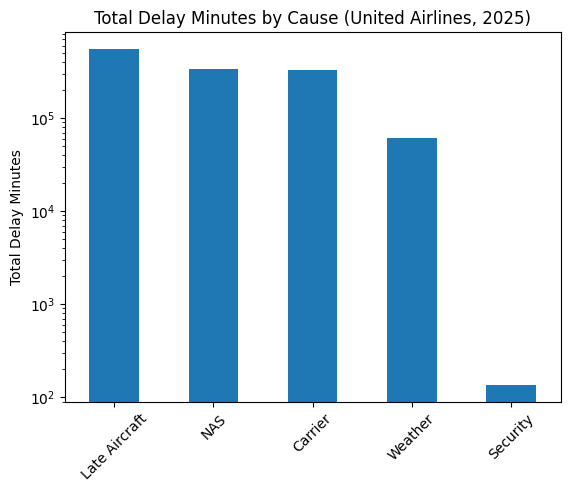

In [87]:
delay_df.plot(kind='bar', logy=True)
plt.title("Total Delay Minutes by Cause (United Airlines, 2025)")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=45)
plt.show()

### Do longer United Airlines flights tend to experience higher departure delays from Newark Liberty International Airport in 2025?

The analysis shows no meaningful relationship between flight duration and departure delays for United Airlines flights departing from Newark Liberty International Airport in 2025. The correlation between scheduled flight time and departure delay is approximately -0.002, which is effectively zero. This indicates that longer flights are not more likely to experience higher departure delays. Instead, departure delays appear to be driven by operational factors at the airport, such as congestion and scheduling constraints, rather than the length of the flight.

In [88]:
df["departure_delay"].corr(df["scheduled_elapsed_time"])

np.float64(-0.002029932117009424)

The scatter plot with regression line shows no visible relationship between flight duration and departure delays. This is consistent with the near-zero correlation value (-0.002), indicating that departure delays are independent of flight length and are more likely driven by operational factors at the origin airport.

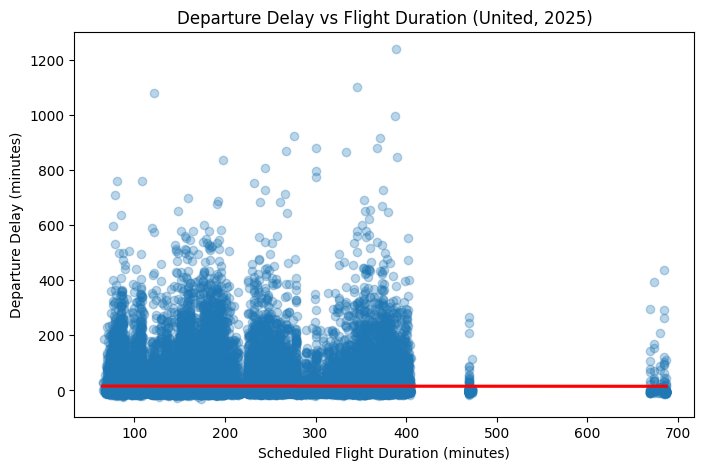

In [89]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="scheduled_elapsed_time",
    y="departure_delay",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Departure Delay vs Flight Duration (United, 2025)")
plt.xlabel("Scheduled Flight Duration (minutes)")
plt.ylabel("Departure Delay (minutes)")

plt.show()

### Which time periods (morning, afternoon, evening, night) are associated with the highest number of delayed departures for United Airlines flights from Newark Liberty International Airport in 2025?

The results show that the highest number of delayed departures for United Airlines flights from Newark Liberty International Airport in 2025 occurs during the evening period, followed closely by the afternoon. Morning flights experience fewer delays, while night departures have the lowest number of delayed flights. This pattern suggests that delays tend to accumulate later in the day, likely due to increasing airport congestion and operational disruptions as flight activity builds up throughout the day.

### Delayed Departures by Time of Day 

To analyze how departure delays are distributed throughout the day, flight departure times were grouped into four time periods: Morning (05:00–11:00), Afternoon (12:00–16:00), Evening (17:00–20:00), and Night (21:00–04:00). The number of delayed departures was then calculated for each period.

In [90]:
## Converting actual departure time to datetime and extracting the hour for time period analysis
df["hour"] = pd.to_datetime(df["actual_dep_time"], format="%H:%M").dt.hour

def time_period(hour):
    if 5 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 20:
        return "Evening"
    else:
        return "Night"

df["time_period"] = df["hour"].apply(time_period)

### Creating a Delay Indicator Variable

To analyze flight delays more effectively, a new boolean column was created to classify each flight as either delayed or not delayed. A flight is considered delayed if its departure delay is greater than 0 minutes.

In [91]:
df["is_delayed"] = df["departure_delay"] > 0

### Number of Delayed Departures by Time of Day

To understand when delays are most frequent, we filtered only delayed flights and grouped them by time of day (Morning, Afternoon, Evening, Night). The result shows the number of delayed departures occurring in each period.

In [92]:
delay_counts = df[df["is_delayed"]].groupby("time_period").size()
print(delay_counts)

time_period
Afternoon    6935
Evening      7283
Morning      5788
Night        4191
dtype: int64


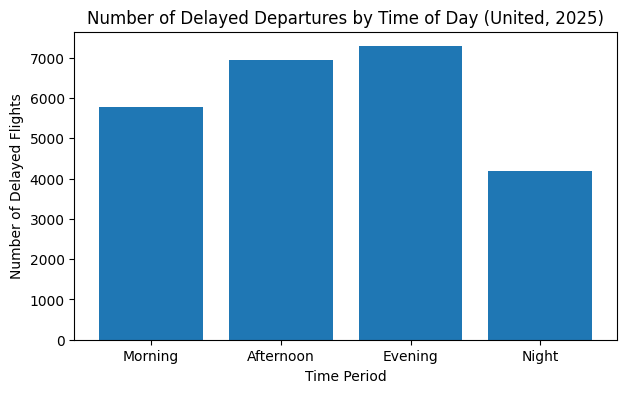

In [93]:
delay_counts = delay_counts.reindex(["Morning", "Afternoon", "Evening", "Night"])

plt.figure(figsize=(7,4))
plt.bar(delay_counts.index, delay_counts.values)

plt.title("Number of Delayed Departures by Time of Day (United, 2025)")
plt.xlabel("Time Period")
plt.ylabel("Number of Delayed Flights")

plt.show()

### Key Takeaways
- Cancellations were minimal (1.34%)
- Delays are mainly caused by late aircraft and airspace congestion (NAS)
- Evening is the most delay-prone time period
- Certain destinations and aircraft show higher delay concentration
- Flight length does not influence departure delays

### Conclusion

This project analyzed United Airlines flight operations from Newark Liberty International Airport in 2025 to identify patterns in delays and operational performance.

Overall, the percentage of canceled flights was very low at 1.34%, indicating that cancellations were not a major factor in overall flight disruptions. Most issues in the dataset were related to delays rather than cancellations.

Delay analysis showed that certain aircraft tails experienced repeated delays, with specific tail numbers such as N13110 and N19141 appearing most frequently among delayed flights. This suggests that some aircraft may be more affected by scheduling or operational rotation issues.

When examining delay causes, the largest contributors were Late Aircraft delays (554,914) and NAS (National Airspace System) delays (340,595), followed by Carrier-related delays (328,249). Weather and security-related delays were significantly lower, indicating that most disruptions were driven by airline operations and air traffic system congestion rather than external environmental factors.

Time-of-day analysis showed that delays were not evenly distributed. Evening flights had the highest number of delays (7,283), followed closely by afternoon flights (6,935). Morning flights experienced fewer delays, while night flights had the lowest (4,191). This suggests that delays accumulate throughout the day due to increasing congestion and operational pressure.

Destination analysis also revealed strong variation in performance. Some routes, such as Louisville International Airport (SDF), experienced extremely high average departure delays compared to other destinations, making it a clear outlier in the dataset.

Finally, there was no meaningful relationship between flight duration and departure delays (correlation ≈ -0.002), showing that longer flights are not more likely to be delayed.

### References
County College of Morris. (2026). Course Module: 1 - 13.  Blackboard

Bureau of Transportation Statistics. (2025). On-time performance – flight departures. https://transtats.bts.gov/ONTIME/Departures.aspx

OpenAI. (2026). ChatGPT (May 2026 version) [Large language model]. https://chat.openai.com/

Google. (2026). Gemini (May 2026 version) [Large language model]. https://gemini.google.com/